# Creating Temporally and Spatially Consistent Channel-Matrix Sequences

This notebook demonstrates how to use NeoRadium's [TrjChannel.getChanSeqGen](https://ail-wireless.pages.interdigital.com/neoradium/source/API/Channels.html#neoradium.trjchan.TrjChannel.getChanSeqGen) method to create temporally and spatially consistent sequences of channel matrices from a trajectory-based channel model.

The notebook first opens a [DeepMIMO](https://www.deepmimo.net) scenario, creates a random UE trajectory, and then creates a [TrjChannel](https://ail-wireless.pages.interdigital.com/neoradium/source/API/Channels.html#neoradium.trjchan.TrjChannel) object from that trajectory. The trajectory-based channel is then used to generate sequences of channel matrices as the UE moves along the trajectory.

Two examples are shown:

1. **Raw channel-matrix sequences:** [getChanSeqGen](https://ail-wireless.pages.interdigital.com/neoradium/source/API/Channels.html#neoradium.trjchan.TrjChannel.getChanSeqGen) is used to generate sequences of channel matrices sampled along the trajectory. Each sequence contains multiple channel snapshots separated by a fixed number of trajectory points.
2. **Effective channel-matrix sequences with callbacks:** [getChanSeqGen](https://ail-wireless.pages.interdigital.com/neoradium/source/API/Channels.html#neoradium.trjchan.TrjChannel.getChanSeqGen) is used with callback functions to generate effective channel matrices after PDSCH-based precoding. The callbacks are used to process individual channel matrices and optionally filter generated sequences.

The generated channel sequences are stacked into NumPy arrays so that their dimensions can be inspected and used as datasets for further processing.

### Notes

- The generated channel matrices are temporally and spatially consistent because they are obtained from consecutive points along the same UE trajectory.
- The `seqPeriod` parameter controls the spacing, in trajectory points, between consecutive channel matrices within a sequence.
- The `seqLen` parameter controls the number of channel matrices in each sequence.
- The `maxNumSeq` parameter limits the maximum number of generated sequences.
- Callback functions can be used to modify individual channel matrices, drop blocked channels, or post-process complete sequences.
- The user may need to update the `dataFolder` variable based on the location of the DeepMIMO scenario files on their system.


In [1]:
import numpy as np
from neoradium import DeepMimoData, TrjChannel, BandwidthPart, PDSCH, AntennaPanel, random

In [2]:
# Replace this with the folder on your system where the DeepMIMO scenarios are stored
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
deepMimoData = DeepMimoData("asu_campus_3p5")
deepMimoData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%




Trajectory Properties:
  start (x,y,z):          (-164.55, 69.83, 1.50)
  No. of points:          200,368
  curIdx:                 0 (0.00%)
  curSpeed:               [0.85 0.85 0.  ]
  Total distance:         240.42 meters
  Total time:             200.367 seconds
  Average Speed:          1.200 m/s
  Carrier Frequency:      3.5 GHz
  Paths (Min, Avg, Max):  5, 8.79, 10
  Totally blocked:        0
  LOS percentage:         59.42%



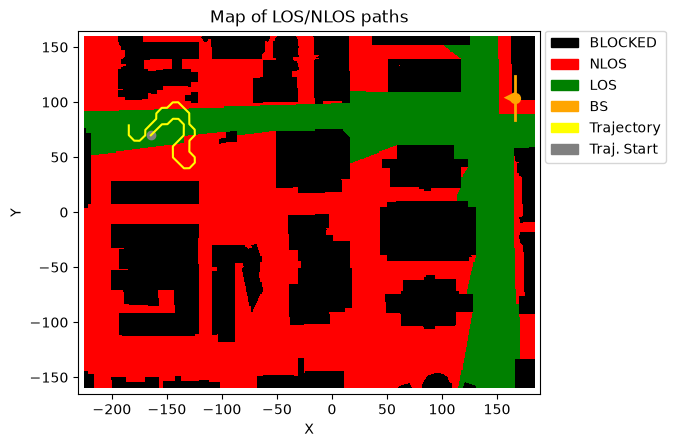

In [3]:
random.setSeed(123)                                 # Make results reproducible
bwp = BandwidthPart(numRbs=24, spacing=15)          # Create a BandwidthPart object

# Create a random trajectory
trajectory = deepMimoData.getRandomTrajectory(xyBounds=np.array([[-210, 40], [-120, 100]]),   # Trajectory bounds
                                              segLen=5,     # Number of DeepMIMO grid points on the shortest segment
                                              bwp=bwp,      # The bandwidth part
                                              trajLen=200,  # Number of DeepMIMO grid points on the trajectory
                                              speedMps=1.2) # Speed in m/s

trajectory.print()                                  # Print the trajectory information
ax = deepMimoData.drawMap("LOS-NLOS", trajectory)   # Draw the map with the trajectory
deepMimoData.drawBsPanel(ax, 180)                   # TX antenna with a 180-degree bearing angle

In [4]:
# Create a trajectory-based channel model
channel = TrjChannel(bwp, trajectory,
                     txOrientation = [180,0,0], # BS antenna facing the left side of the map
                     txAntenna = AntennaPanel([2,4], polarization="x"), # 16 TX antennas
                     rxAntenna = AntennaPanel([1,2], polarization="x")) # 4 RX antennas
print(channel)


TrjChannel Properties:
  carrierFreq:              3.5 GHz
  normalizeGains:           True
  normalizeOutput:          True
  normalizeDelays:          True
  xPolPower:                10.00 (dB)
  filterLen:                16 samples
  delayQuantSize:           64
  stopBandAtten:            80 dB
  dopplerShift:             14.02 Hz
  coherenceTime:            30.191 milliseconds
  TX Antenna:
    Total Elements:         16
    spacing:                0.5𝜆, 0.5𝜆
    shape:                  2 rows x 4 columns
    polarization:           x
    Orientation (𝛼,𝛃,𝛄):     180° 0° 0°
  RX Antenna:
    Total Elements:         4
    spacing:                0.5𝜆, 0.5𝜆
    shape:                  1 rows x 2 columns
    polarization:           x
  Trajectory:
    start (x,y,z):          (-164.55, 69.83, 1.50)
    No. of points:          200,368
    curIdx:                 0 (0.00%)
    curSpeed:               [0.85 0.85 0.  ]
    Total distance:         240.42 meters
    Total time:           

In [5]:
# Create a sequence generator that generates up to 20 sequences.
# Each sequence contains 10 channel matrices sampled every 2 trajectory points.
# For example, the first sequence uses trajectory points 0, 2, 4, ..., 18.

# Trajectory Points:         0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 ...
# Channels in the sequence:  0   1   2   3   4   5     6     7     8     9     0     1  ...
# Sequence Number:           0   0   0   0   0   0     0     0     0     0     1     1  ...
chanSeqGen = channel.getChanSeqGen(seqPeriod=2, seqLen=10, maxNumSeq=20)


In [6]:
chanSeqGen.reset()  # Reset so this cell can be rerun and produce the same sequence list
for i, chanSeq in enumerate(chanSeqGen):
    print(f"Shape of sequence {i}: {chanSeq.shape}")

Shape of sequence 0: (10, 14, 288, 4, 16)
Shape of sequence 1: (10, 14, 288, 4, 16)
Shape of sequence 2: (10, 14, 288, 4, 16)
Shape of sequence 3: (10, 14, 288, 4, 16)
Shape of sequence 4: (10, 14, 288, 4, 16)
Shape of sequence 5: (10, 14, 288, 4, 16)
Shape of sequence 6: (10, 14, 288, 4, 16)
Shape of sequence 7: (10, 14, 288, 4, 16)
Shape of sequence 8: (10, 14, 288, 4, 16)
Shape of sequence 9: (10, 14, 288, 4, 16)
Shape of sequence 10: (10, 14, 288, 4, 16)
Shape of sequence 11: (10, 14, 288, 4, 16)
Shape of sequence 12: (10, 14, 288, 4, 16)
Shape of sequence 13: (10, 14, 288, 4, 16)
Shape of sequence 14: (10, 14, 288, 4, 16)
Shape of sequence 15: (10, 14, 288, 4, 16)
Shape of sequence 16: (10, 14, 288, 4, 16)
Shape of sequence 17: (10, 14, 288, 4, 16)
Shape of sequence 18: (10, 14, 288, 4, 16)
Shape of sequence 19: (10, 14, 288, 4, 16)


In [7]:
# The following example uses the callback functions to modify the channel sequences 
channel = TrjChannel(bwp, trajectory,
                     txOrientation = [180,0,0], # BS antenna facing the left side of the map
                     txAntenna = AntennaPanel([2,4], polarization="x"), # 16 TX antennas
                     rxAntenna = AntennaPanel([1,2], polarization="x")) # 4 RX antennas
pdsch = PDSCH(bwp, numLayers=2, modulation="16QAM") # Create a PDSCH object with two layers


# Channel callback used to process each channel matrix
def chanCallback(seqNo, elementNo, channelMatrix, channel):
    # Drop sequences that include a totally blocked channel
    return None if channel.totalBlockage else channelMatrix
    
# Sequence callback used to process each complete channel sequence
def seqCallback(seqNo, channelSeq, channel):
    # Get the precoding matrix based on the first channel in the sequence
    precoder = pdsch.getPrecodingMatrix(channelSeq[0])
    # Now create and return a new sequence containing the effective channels by applying 
    # the precoder to all channels in the sequence. Each effective channel is an 
    # L x K x Nr x Nl tensor.
    newSeq = np.stack([channel.getEffChannel(chanMat, precoder) for chanMat in channelSeq])  
    return newSeq        

chanSeqGen = channel.getChanSeqGen(seqPeriod=1, seqLen=5, maxNumSeq=20, 
                                   chanCallback=chanCallback, seqCallback=seqCallback)

channelSequences = np.stack([chanSeq for chanSeq in chanSeqGen])  # Stack generated sequences into one array
print(channelSequences.shape)   # Prints: (20, 5, 14, 288, 4, 2) for (numSeq, seqLen, L, K, Nr, Nl)


(20, 5, 14, 288, 4, 2)
